In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score, jaccard_score
from skimage.transform import resize
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import pydicom
from sklearn.model_selection import train_test_split


# Dataset paths
dataset_path = "../input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/"
train_images_dir = os.path.join(dataset_path, "stage_2_train/")
train_csv = os.path.join(dataset_path, "stage_2_train.csv")

# Load and preprocess train.csv
train = pd.read_csv(train_csv)
train['id'] = train['ID'].apply(lambda st: "ID_" + st.split('_')[1])
train['subtype'] = train['ID'].apply(lambda st: st.split('_')[2])
train = train[["id", "subtype", "Label"]]

# Identify and remove duplicate entries
duplicates = train[train.duplicated(subset=['id', 'subtype'], keep=False)]
print(f"Number of duplicate rows: {len(duplicates)}")

if not duplicates.empty:
    print("Removing duplicate entries...")
    train = train.drop_duplicates(subset=['id', 'subtype'])
    print("Duplicates removed.")

# Check for missing labels
missing_labels = train[train['Label'].isnull()]
print(f"Number of missing labels: {len(missing_labels)}")

if not missing_labels.empty:
    print("Filling missing labels with 0...")
    train['Label'] = train['Label'].fillna(0)
    print("Missing labels filled.")

# Pivot the data
train_pivot = train.pivot(index='id', columns='subtype', values='Label').reset_index()
print("Pivoted DataFrame shape:", train_pivot.shape)
print(train_pivot.head())

# Add file paths
train_pivot['file_path'] = train_pivot['id'].apply(lambda x: os.path.join(train_images_dir, f"{x}.dcm"))

#smaller subset for testing
subset = train_pivot.sample(n=2000, random_state=42)
print(f"Using {len(subset)} samples for training.")

# Preprocess DICOM images
def preprocess_dicom(file_path, label, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
        img = np.repeat(img, 3, axis=-1)   # Convert grayscale to RGB
        img = img / np.max(img)           # Normalize pixel values
        return img, label
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None
        
# Process the subset and create image-label pairs
images, labels = [], []
for _, row in subset.iterrows():
    img, lbl = preprocess_dicom(
        row['file_path'],
        row[["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]].values
    )
    if img is not None:
        images.append(img)
        labels.append(lbl)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)
print("Preprocessed images shape:", images.shape)
print("Preprocessed labels shape:", labels.shape)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

def create_densenet_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="sigmoid")  # Multi-label classification
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Create and compile the model
model = create_densenet_model()

model.save('densenet_model.h5')

# Convert labels to float32
labels = np.array(labels, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=32)

# Check data shapes and types
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("X_val shape:", X_val.shape, "dtype:", X_val.dtype)
print("y_val shape:", y_val.shape, "dtype:", y_val.dtype)

# Predict on validation data
densenet_y_pred = model.predict(X_val)
densenet_y_pred_binary = (densenet_y_pred > 0.5).astype(int)

Number of duplicate rows: 48
Removing duplicate entries...
Duplicates removed.
Number of missing labels: 0
Pivoted DataFrame shape: (752803, 7)
subtype            id  any  epidural  intraparenchymal  intraventricular  \
0        ID_000012eaf    0         0                 0                 0   
1        ID_000039fa0    0         0                 0                 0   
2        ID_00005679d    0         0                 0                 0   
3        ID_00008ce3c    0         0                 0                 0   
4        ID_0000950d7    0         0                 0                 0   

subtype  subarachnoid  subdural  
0                   0         0  
1                   0         0  
2                   0         0  
3                   0         0  
4                   0         0  
Using 2000 samples for training.
Preprocessed images shape: (2000, 224, 224, 3)
Preprocessed labels shape: (2000, 6)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
50/50 ━━━━━━━━━━━

In [2]:
# Calculate evaluation metrics
from sklearn.metrics import accuracy_score

DenseNet121_f1 = f1_score(y_val, densenet_y_pred_binary, average='weighted', zero_division=1)
DenseNet121_precision = precision_score(y_val, densenet_y_pred_binary, average='weighted', zero_division=1)
DenseNet121_recall = recall_score(y_val, densenet_y_pred_binary, average='weighted', zero_division=1)
accuracy = accuracy_score(y_val, densenet_y_pred_binary)

# Sensitivity (Recall per class)
from sklearn.metrics import classification_report
DenseNet121_report = classification_report(
    y_val, 
    densenet_y_pred_binary, 
    target_names=['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural', 'any'], 
    zero_division=1
)
print(DenseNet121_report)

# Store training and validation metrics
DenseNet121_training_accuracy = history.history['accuracy'][-1]
DenseNet121_training_loss = history.history['loss'][-1]
DenseNet121_validation_accuracy = history.history['val_accuracy'][-1]
DenseNet121_validation_loss = history.history['val_loss'][-1]

# Print metrics using new variables
print(f"DenseNet121 Accuracy: {accuracy:.4f}")
print(f"DenseNet121 Training Accuracy: {DenseNet121_training_accuracy:.4f}")
print(f"DenseNet121 Training Loss: {DenseNet121_training_loss:.4f}")
print(f"DenseNet121 Validation Accuracy: {DenseNet121_validation_accuracy:.4f}")
print(f"DenseNet121 Validation Loss: {DenseNet121_validation_loss:.4f}")

print(f"DenseNet121 F1 Score: {DenseNet121_f1:.4f}")
print(f"DenseNet121 Precision: {DenseNet121_precision:.4f}")
print(f"DenseNet121 Recall (Sensitivity): {DenseNet121_recall:.4f}")

                  precision    recall  f1-score   support

        epidural       1.00      0.00      0.00         1
intraparenchymal       1.00      0.00      0.00        26
intraventricular       1.00      0.00      0.00        18
    subarachnoid       1.00      0.00      0.00        22
        subdural       1.00      0.00      0.00        22
             any       1.00      0.03      0.06        69

       micro avg       1.00      0.01      0.02       158
       macro avg       1.00      0.00      0.01       158
    weighted avg       1.00      0.01      0.02       158
     samples avg       1.00      0.83      0.83       158

DenseNet121 Accuracy: 0.8275
DenseNet121 Training Accuracy: 0.0256
DenseNet121 Training Loss: 0.1852
DenseNet121 Validation Accuracy: 0.0000
DenseNet121 Validation Loss: 0.1960
DenseNet121 F1 Score: 0.0246
DenseNet121 Precision: 1.0000
DenseNet121 Recall (Sensitivity): 0.0127


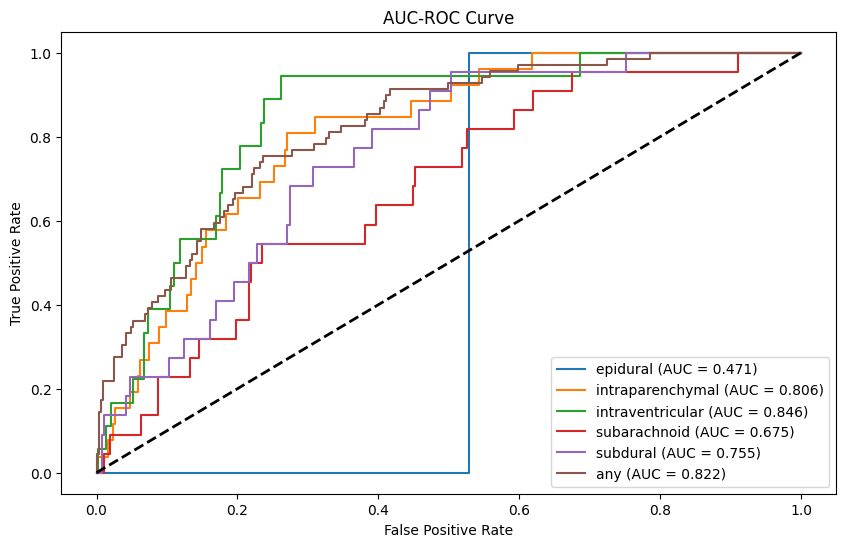

In [3]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

for i, label in enumerate(["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]):
    fpr, tpr, _ = roc_curve(y_val[:, i], densenet_y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()

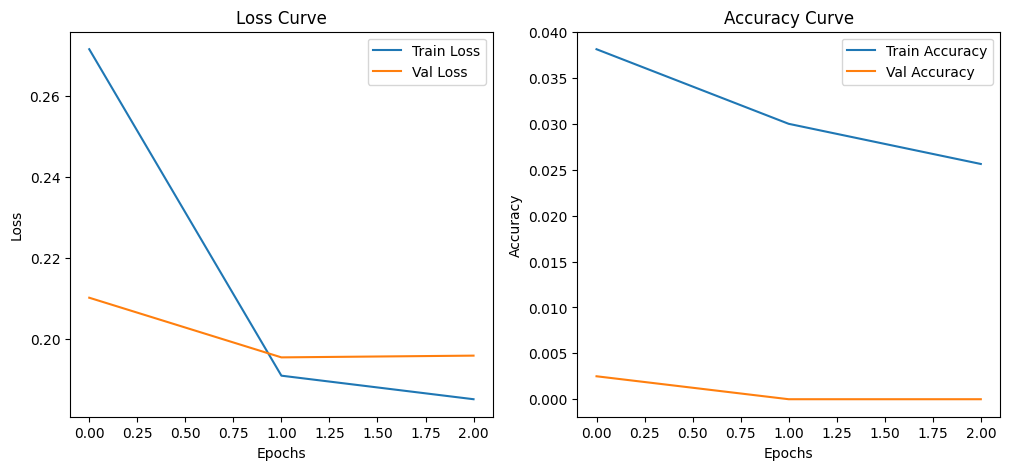

In [4]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
epidural: Hemorrhage Detected (0.66)
intraparenchymal: No Hemorrhage (0.39)
intraventricular: Hemorrhage Detected (0.87)
subarachnoid: No Hemorrhage (0.34)
subdural: No Hemorrhage (0.15)
any: Hemorrhage Detected (0.66)


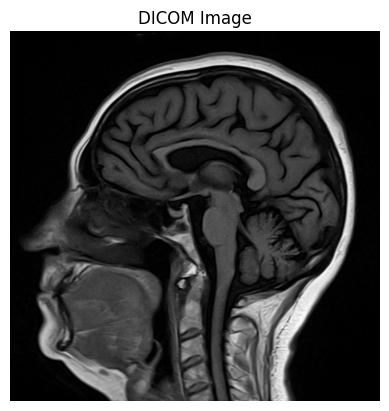

In [7]:
import numpy as np
import pydicom
import os
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("densenet_model.h5")

# Define image path
image_path = "/kaggle/input/images/1-1.dcm"

def preprocess_dicom(file_path, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
        img = np.repeat(img, 3, axis=-1)    # Convert grayscale to RGB
        img = img / np.max(img) if np.max(img) > 0 else img  # Normalize
        return np.expand_dims(img, axis=0)  # Add batch dimension
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Preprocess the image
image = preprocess_dicom(image_path)
if image is not None:
    # Predict
    predictions = model.predict(image)[0]
    
    # Define hemorrhage subtypes
    hemorrhage_types = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]
    
    # Print predictions
    for hemorrhage, prob in zip(hemorrhage_types, predictions):
        print(f"{hemorrhage}: {'Hemorrhage Detected' if prob > 0.5 else 'No Hemorrhage'} ({prob:.2f})")
    
    # Display image
    dicom = pydicom.dcmread(image_path)
    plt.imshow(dicom.pixel_array, cmap='gray')
    plt.title("DICOM Image")
    plt.axis("off")
    plt.show()
else:
    print("Failed to process the image.")